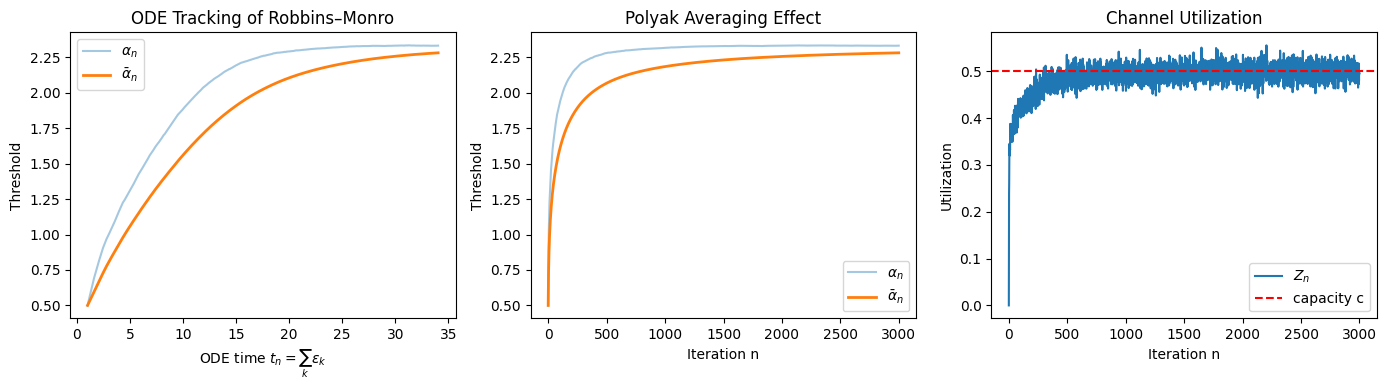

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# SYSTEM PARAMETERS
# =========================
N = 4
r = np.array([100, 50, 10, 1])
p = np.array([1/3, 1/12, 1/4, 1/3])
λ = 1e5
c = 0.5

ε0 = 1.0
γ = 0.7                  # γ ∈ (1/2, 1]
T = 0.01
N_iter = 3000

# =========================
# THRESHOLD POLICY
# =========================
def admit(α, j):
    k = int(np.floor(α))
    if j < k:
        return 1
    elif j == k:
        return np.random.rand() < (α - k)
    else:
        return 0

# =========================
# ROBBINS–MONRO + POLYAK + ODE TIME
# =========================
α = 0.0
α_bar = 0.0              # Polyak average
t = 0.0                  # ODE timescale

α_history = []
α_bar_history = []
Z_history = []
t_history = []

for n in range(1, N_iter + 1):

    # decreasing stepsize
    ε_n = ε0 / (n ** γ)

    # ODE time update
    t += ε_n

    # arrivals in window T
    arrivals = np.random.poisson(λ * T)
    admitted = 0

    for _ in range(arrivals):
        j = np.random.choice(N, p=p)
        admitted += admit(α, j)

    # utilization estimate
    Z_n = admitted / arrivals if arrivals > 0 else 0.0

    # Robbins–Monro update
    α = α + ε_n * (c - Z_n)
    α = np.clip(α, 0, N)

    # Polyak averaging
    α_bar = α_bar + (α - α_bar) / n

    # store histories
    α_history.append(α)
    α_bar_history.append(α_bar)
    Z_history.append(Z_n)
    t_history.append(t)

# =========================
# PLOTS
# =========================
plt.figure(figsize=(14, 4))

# ---- ODE tracking ----
plt.subplot(1, 3, 1)
plt.plot(t_history, α_history, alpha=0.4, label=r"$\alpha_n$")
plt.plot(t_history, α_bar_history, linewidth=2, label=r"$\bar{\alpha}_n$")
plt.xlabel(r"ODE time $t_n = \sum_k \varepsilon_k$")
plt.ylabel("Threshold")
plt.legend()
plt.title("ODE Tracking of Robbins–Monro")

# ---- Polyak effect ----
plt.subplot(1, 3, 2)
plt.plot(α_history, alpha=0.4, label=r"$\alpha_n$")
plt.plot(α_bar_history, linewidth=2, label=r"$\bar{\alpha}_n$")
plt.xlabel("Iteration n")
plt.ylabel("Threshold")
plt.legend()
plt.title("Polyak Averaging Effect")

# ---- Utilization ----
plt.subplot(1, 3, 3)
plt.plot(Z_history, label=r"$Z_n$")
plt.axhline(c, color="red", linestyle="--", label="capacity c")
plt.xlabel("Iteration n")
plt.ylabel("Utilization")
plt.legend()
plt.title("Channel Utilization")

plt.tight_layout()
plt.show()
